# Deng control-volume reconstruction for the conforming fracture MMS

This notebook applies the Deng-Ginting-McCaskill local post-processing to the conforming fractured MMS problem. The fracture multiplier is treated as a source term in the nodal control-volume balance. Each tagged fracture facet is split at its midpoint, and the two half-facet multiplier integrals are assigned to the endpoint control volumes.

In [8]:
# ============================================================
# Configuration and imports
# ============================================================
from mpi4py import MPI
import numpy as np
import math
import time
import pathlib
import basix
import matplotlib.pyplot as plt
from tqdm import tqdm

from dolfinx import mesh, fem, geometry
from dolfinx.fem import petsc
try:
    from dolfinx.io import gmsh as gmshio
except ImportError:
    from dolfinx.io import gmshio
import ufl

order = 1
Gamma_tag = 2

# Section 0: convergence analysis. Keep False for a quick diagnostic run.
RUN_CONVERGENCE = False
CONV_REFS = [3, 4, 5, 6]

# Main comparison run, matching the PINN MMS comparison table.
REF_DEMO = 6

# Jump/error summaries exclude the tip layer below.
TIP_FRAC = 0.10

# Residual-map color range. Values outside this range are saturated.
RK_LOG_VMIN = -10.0
RK_LOG_VMAX = -1.0
RK_CBAR_TICKS = np.arange(RK_LOG_VMIN, RK_LOG_VMAX + 1, 1, dtype=float)

Lx, Ly = 1.0, 1.0
x_start, x_end = 0.0, 1.0
y_start, y_end = 0.0, 1.0
ALPHA = 1.0
K_M_VALUE = 1.0
K_F_VALUE = 100.0

plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
})

In [9]:
# ============================================================
# MMS data
# ============================================================
def mesh_path_for_ref(ref):
    name = f"regular_mesh_with_fracture_{ref}.msh"
    candidates = [
        pathlib.Path.cwd() / name,
        pathlib.Path.cwd() / "fenicsx/code/fracture problem" / name,
        pathlib.Path("fenicsx/code/fracture problem") / name,
    ]
    for p in candidates:
        if p.exists():
            return str(p)
    raise FileNotFoundError(f"Could not find {name}; tried: " + ", ".join(str(p) for p in candidates))


def q_exact_xy(x0, y0):
    return np.sin(np.pi * x0) * np.sin(np.pi * y0)


def r_exact_xy(x0, y0):
    return (x0 - y0) / np.sqrt(2.0)


def p_m_exact_xy(x0, y0):
    q = q_exact_xy(x0, y0)
    return q + ALPHA * np.abs(r_exact_xy(x0, y0)) * q


def p_m_exact_fn(x):
    return p_m_exact_xy(x[0], x[1])


def p_f_exact_fn(t):
    return np.sin(np.pi * t) ** 2


def lam_exact_fn(t):
    return -2.0 * ALPHA * np.sin(np.pi * t) ** 2


def f_m_exact_xy(x0, y0):
    q = q_exact_xy(x0, y0)
    r = r_exact_xy(x0, y0)
    sign_r = np.where(r >= 0.0, 1.0, -1.0)
    return (
        2.0 * np.pi**2 * q
        + 2.0 * ALPHA * np.pi**2 * np.abs(r) * q
        - ALPHA * np.sqrt(2.0) * np.pi * sign_r * np.sin(np.pi * (y0 - x0))
    )


def f_m_exact_points(points):
    points = np.asarray(points, dtype=float)
    return f_m_exact_xy(points[:, 0], points[:, 1])


def f_callable(x):
    return f_m_exact_xy(x[0], x[1])


def ff_callable(x):
    t = x[0]
    return -K_F_VALUE * np.pi**2 * np.cos(2.0 * np.pi * t) + lam_exact_fn(t)


def k_callable(x):
    return (x[0] * 0.0 + K_M_VALUE)[np.newaxis, :]


def exact_grad_p(points):
    pts = np.asarray(points, dtype=float)
    x = pts[:, 0]
    y = pts[:, 1]
    q = q_exact_xy(x, y)
    r = r_exact_xy(x, y)
    abs_r = np.abs(r)
    sign_r = np.where(r >= 0.0, 1.0, -1.0)
    dqdx = np.pi * np.cos(np.pi * x) * np.sin(np.pi * y)
    dqdy = np.pi * np.sin(np.pi * x) * np.cos(np.pi * y)
    drdx = 1.0 / np.sqrt(2.0)
    drdy = -1.0 / np.sqrt(2.0)
    grad = np.zeros((len(pts), 2), dtype=float)
    grad[:, 0] = dqdx + ALPHA * (sign_r * drdx * q + abs_r * dqdx)
    grad[:, 1] = dqdy + ALPHA * (sign_r * drdy * q + abs_r * dqdy)
    return grad


def exact_q(points):
    return -K_M_VALUE * exact_grad_p(points)

In [10]:
# ============================================================
# LCG solve for the conforming fracture MMS
# ============================================================
def solve_lcg_mms(ref, verbose=False):
    filename = mesh_path_for_ref(ref)
    msh, cell_markers, facet_markers = gmshio.read_from_msh(
        filename, MPI.COMM_WORLD, 0, gdim=2
    )[0:3]
    comm = msh.comm

    tdim = msh.topology.dim
    fdim = tdim - 1
    omega = msh
    gamma_entities = facet_markers.find(Gamma_tag)
    gamma, gamma_to_omega, gamma_vertex_to_omega = mesh.create_submesh(
        omega, fdim, gamma_entities
    )[0:3]

    V_m = fem.functionspace(omega, ("Lagrange", order))
    V_f = fem.functionspace(gamma, ("Lagrange", order))
    V_l = fem.functionspace(gamma, ("Lagrange", order))
    W = ufl.MixedFunctionSpace(V_m, V_f, V_l)

    phi, psi, mu = ufl.TestFunctions(W)
    dp_m, dp_f, dl = ufl.TrialFunctions(W)
    p_m = fem.Function(V_m, name="p_m")
    p_f = fem.Function(V_f, name="p_f")
    lmbd = fem.Function(V_l, name="lmbd")

    x = ufl.SpatialCoordinate(omega)
    q_ufl = ufl.sin(np.pi * x[0]) * ufl.sin(np.pi * x[1])
    r_ufl = (x[0] - x[1]) / np.sqrt(2.0)
    abs_r_ufl = ufl.conditional(ufl.ge(r_ufl, 0.0), r_ufl, -r_ufl)
    sign_r_ufl = ufl.conditional(ufl.ge(r_ufl, 0.0), 1.0, -1.0)
    f_m_ufl = (
        2.0 * np.pi**2 * q_ufl
        + 2.0 * ALPHA * np.pi**2 * abs_r_ufl * q_ufl
        - ALPHA * np.sqrt(2.0) * np.pi * sign_r_ufl * ufl.sin(np.pi * (x[1] - x[0]))
    )

    f_m = fem.Function(V_m, name="f_m")
    f_m.interpolate(f_callable)
    f_f = fem.Function(V_f, name="f_f")
    f_f.interpolate(ff_callable)
    k_m = fem.Function(V_m, name="k_m")
    k_m.interpolate(k_callable)
    k_f = fem.Function(V_f, name="k_f")
    k_f.x.array[:] = K_F_VALUE

    dx = ufl.Measure("dx", domain=omega)
    ds = ufl.Measure("ds", domain=omega, subdomain_data=facet_markers, subdomain_id=Gamma_tag)
    dx_f = ufl.Measure("dx", domain=gamma)

    coords = omega.geometry.x
    xmin, xmax = coords[:, 0].min(), coords[:, 0].max()
    ymin, ymax = coords[:, 1].min(), coords[:, 1].max()
    tol = 1e-10 * max(xmax - xmin, ymax - ymin)

    a_m0 = ufl.inner(k_m * ufl.grad(p_m), ufl.grad(phi)) * dx
    a_m1 = -lmbd * phi * ds
    L_m = f_m_ufl * phi * dx

    a_f0 = ufl.inner(k_f * ufl.grad(p_f), ufl.grad(psi)) * ds
    a_f1 = lmbd * psi * ds
    L_f = f_f * psi * ds

    a_l0 = p_m * mu * ds
    a_l1 = -p_f * mu * ds
    L_l = fem.Constant(omega, 0.0) * mu * ds

    F = (a_m0 + a_m1 - L_m) + (a_f0 + a_f1 - L_f) + (a_l0 + a_l1 - L_l)
    residual = ufl.extract_blocks(F)
    jac = ufl.derivative(F, p_m, dp_m) + ufl.derivative(F, p_f, dp_f) + ufl.derivative(F, lmbd, dl)
    J = ufl.extract_blocks(jac)

    left_dofs = fem.locate_dofs_geometrical(V_m, lambda x: np.isclose(x[0], xmin, atol=tol))
    right_dofs = fem.locate_dofs_geometrical(V_m, lambda x: np.isclose(x[0], xmax, atol=tol))
    bottom_dofs = fem.locate_dofs_geometrical(V_m, lambda x: np.isclose(x[1], ymin, atol=tol))
    top_dofs = fem.locate_dofs_geometrical(V_m, lambda x: np.isclose(x[1], ymax, atol=tol))
    all_dofs = np.unique(np.concatenate([left_dofs, right_dofs, bottom_dofs, top_dofs]))
    p_m_bc = fem.Function(V_m)
    p_m_bc.x.array[:] = 0.0
    bc_pm = fem.dirichletbc(p_m_bc, all_dofs)

    tol_g = 1e-10 * np.max(np.ptp(gamma.geometry.x, axis=0))
    tip1_dofs = fem.locate_dofs_geometrical(
        V_f,
        lambda x: np.logical_and(np.isclose(x[0], x_start, atol=tol_g),
                                 np.isclose(x[1], y_start, atol=tol_g)),
    )
    tip2_dofs = fem.locate_dofs_geometrical(
        V_f,
        lambda x: np.logical_and(np.isclose(x[0], x_end, atol=tol_g),
                                 np.isclose(x[1], y_end, atol=tol_g)),
    )
    both_tips = np.unique(np.concatenate([tip1_dofs, tip2_dofs]))
    pf_bc = fem.Function(V_f)
    pf_bc.x.array[:] = 0.0
    bc_pf = fem.dirichletbc(pf_bc, both_tips)

    petsc_options = {
        "snes_max_it": 200,
        "ksp_type": "preonly",
        "pc_type": "lu",
        "pc_factor_mat_solver_type": "mumps",
        "mat_mumps_icntl_14": 120,
        "ksp_error_if_not_converged": True,
        "snes_error_if_not_converged": True,
    }
    if verbose:
        petsc_options["snes_monitor"] = None

    nlp = petsc.NonlinearProblem(
        residual,
        u=[p_m, p_f, lmbd],
        J=J,
        bcs=[bc_pm, bc_pf],
        entity_maps=[gamma_to_omega],
        petsc_options=petsc_options,
        petsc_options_prefix=f"deng_frac_ref{ref}_",
    )
    nlp.solve()
    iterations = nlp.solver.getIterationNumber()

    # Select the multiplier sign used in the local-conservation balance.
    lam_coords = V_l.tabulate_dof_coordinates()[:, 0]
    lam_raw = lmbd.x.array[:len(lam_coords)]
    lam_ex = lam_exact_fn(lam_coords)
    err_plus = float(np.linalg.norm(lam_raw - lam_ex))
    err_minus = float(np.linalg.norm(-lam_raw - lam_ex))
    lambda_balance_sign = 1.0 if err_plus <= err_minus else -1.0

    p_m_ex = fem.Function(V_m)
    p_m_ex.interpolate(p_m_exact_fn)
    p_f_ex = fem.Function(V_f)
    p_f_ex.interpolate(lambda x: p_f_exact_fn(x[0]))

    def sqrt_global(form_expr):
        local = fem.assemble_scalar(fem.form(form_expr))
        return np.sqrt(comm.allreduce(local, op=MPI.SUM))

    err_pm = sqrt_global((p_m - p_m_ex) ** 2 * dx)
    err_pf = sqrt_global((p_f - p_f_ex) ** 2 * dx_f)
    t_gamma = ufl.SpatialCoordinate(gamma)[0]
    lam_exact_ufl = -2.0 * ALPHA * ufl.sin(np.pi * t_gamma) ** 2
    err_lam = sqrt_global((lambda_balance_sign * lmbd - lam_exact_ufl) ** 2 * dx_f)

    return {
        "ref": ref,
        "h": 1.0 / (2 ** ref),
        "omega": omega,
        "gamma": gamma,
        "gamma_to_omega": gamma_to_omega,
        "gamma_vertex_to_omega": gamma_vertex_to_omega,
        "gamma_entities": gamma_entities,
        "cell_markers": cell_markers,
        "facet_markers": facet_markers,
        "Gamma_tag": Gamma_tag,
        "V": V_m,
        "V_m": V_m,
        "V_f": V_f,
        "V_l": V_l,
        "p_sol": p_m,
        "p_m": p_m,
        "p_f": p_f,
        "lmbd": lmbd,
        "k_m": k_m,
        "f_m": f_m,
        "all_dofs": all_dofs,
        "iterations": iterations,
        "dofs": V_m.dofmap.index_map.size_global,
        "dofs_total": (
            V_m.dofmap.index_map.size_global
            + V_f.dofmap.index_map.size_global
            + V_l.dofmap.index_map.size_global
        ),
        "lambda_balance_sign": lambda_balance_sign,
        "err_pm": err_pm,
        "err_pf": err_pf,
        "err_lam": err_lam,
        "mesh_file": filename,
    }

In [11]:
# ============================================================
# Geometry, quadrature, and field-evaluation helpers
# ============================================================
def cell_centroid(coords):
    return np.mean(coords, axis=0)


def edge_length(a, b):
    return float(np.linalg.norm(b - a))


def normal_from_C_to_ti(centroid, midpoint, vi):
    t = midpoint - centroid
    n1 = np.array([t[1], -t[0]])
    n2 = -n1
    seg_mid = 0.5 * (centroid + midpoint)
    chosen = n1 if np.dot(n1, vi - seg_mid) < 0.0 else n2
    norm = np.linalg.norm(chosen)
    return chosen / norm if norm > 0.0 else chosen


def outward_edge_normal(a, b, centroid):
    t = b - a
    n1 = np.array([t[1], -t[0]])
    n2 = -n1
    mid = 0.5 * (a + b)
    chosen = n1 if np.dot(n1, mid - centroid) > 0.0 else n2
    norm = np.linalg.norm(chosen)
    return chosen / norm if norm > 0.0 else chosen


def unit(v):
    v = np.asarray(v, dtype=float)
    nrm = np.linalg.norm(v)
    if nrm == 0.0:
        raise ValueError("zero-length vector")
    return v / nrm


def polygon_signed_area(poly):
    x = poly[:, 0]
    y = poly[:, 1]
    return 0.5 * np.sum(x * np.roll(y, -1) - np.roll(x, -1) * y)


def order_polygon_vertices(pts):
    pts = np.asarray(pts, dtype=float)
    ctr = pts.mean(axis=0)
    ang = np.arctan2(pts[:, 1] - ctr[1], pts[:, 0] - ctr[0])
    poly = pts[np.argsort(ang)]
    if polygon_signed_area(poly) < 0.0:
        poly = poly[::-1]
    return poly


def extend_line_to_bbox(a, tau, bbox, tol=1e-14):
    xmin, xmax, ymin, ymax = bbox
    ts = []
    if abs(tau[0]) > tol:
        for xval in [xmin, xmax]:
            t = (xval - a[0]) / tau[0]
            y = a[1] + t * tau[1]
            if ymin - tol <= y <= ymax + tol:
                ts.append(t)
    if abs(tau[1]) > tol:
        for yval in [ymin, ymax]:
            t = (yval - a[1]) / tau[1]
            x = a[0] + t * tau[0]
            if xmin - tol <= x <= xmax + tol:
                ts.append(t)
    if len(ts) < 2:
        raise RuntimeError("Could not extend fracture line to bounding box.")
    return min(ts), max(ts)


def _tab(elem, nderiv, pts):
    t = elem.tabulate(nderiv, np.atleast_2d(pts))
    return t[..., 0] if t.ndim == 4 else t


_T_G = np.array([0.5 - 0.5 * np.sqrt(3.0 / 5.0), 0.5, 0.5 + 0.5 * np.sqrt(3.0 / 5.0)])
_W_G = np.array([5.0 / 18.0, 4.0 / 9.0, 5.0 / 18.0])
_T_GAUSS = np.array([(1.0 - 1.0 / np.sqrt(3.0)) / 2.0, (1.0 + 1.0 / np.sqrt(3.0)) / 2.0])
_W_GAUSS = np.array([0.5, 0.5])


def prepare_fracture_geometry(ctx):
    omega = ctx["omega"]
    tdim = omega.topology.dim
    fdim = tdim - 1
    gdim = omega.geometry.dim
    for pair in [(tdim, 0), (tdim, fdim), (fdim, tdim), (fdim, 0), (0, tdim)]:
        omega.topology.create_connectivity(*pair)

    c2v = omega.topology.connectivity(tdim, 0)
    cell_to_facet = omega.topology.connectivity(tdim, fdim)
    facet_to_cell = omega.topology.connectivity(fdim, tdim)
    facet_to_vertex = omega.topology.connectivity(fdim, 0)

    num_cells = omega.topology.index_map(tdim).size_local
    num_facets = omega.topology.index_map(fdim).size_local
    omega_geometry = omega.geometry.x[:, :2]
    local_cell_vertices = [np.asarray(c2v.links(c), dtype=np.int32) for c in range(num_cells)]
    cell_polys = [order_polygon_vertices(omega_geometry[verts]) for verts in local_cell_vertices]
    cell_centroids = np.vstack([poly.mean(axis=0) for poly in cell_polys])
    cell_areas = np.asarray([abs(polygon_signed_area(poly)) for poly in cell_polys])
    h_est = float(np.sqrt(np.mean(cell_areas)))
    facet_by_vertices = {frozenset(int(v) for v in facet_to_vertex.links(fi)): fi for fi in range(num_facets)}
    gamma_facet_set = set(int(f) for f in ctx["facet_markers"].find(ctx["Gamma_tag"]))

    coords = omega.geometry.x
    xmin, xmax = coords[:, 0].min(), coords[:, 0].max()
    ymin, ymax = coords[:, 1].min(), coords[:, 1].max()
    frac_a = np.array([x_start, y_start], dtype=float)
    frac_b = np.array([x_end, y_end], dtype=float)
    tau = unit(frac_b - frac_a)
    normal = np.array([-tau[1], tau[0]], dtype=float)
    L_gamma = float(np.linalg.norm(frac_b - frac_a))
    t_min, t_max = extend_line_to_bbox(frac_a, tau, np.array([xmin, xmax, ymin, ymax], dtype=float))
    ghost_start = frac_a + t_min * tau
    ghost_end = frac_a + t_max * tau

    Wq = fem.functionspace(omega, ("DG", order, (gdim,)))
    q_cg_expr = fem.Expression(-ctx["k_m"] * ufl.grad(ctx["p_sol"]), Wq.element.interpolation_points)
    q_cg_fun = fem.Function(Wq, name="q_cg")
    q_cg_fun.interpolate(q_cg_expr)

    def signed_distance_np(points):
        return (np.asarray(points, dtype=float) - frac_a) @ normal

    def s_coord_np(points):
        return (np.asarray(points, dtype=float) - frac_a) @ tau

    def real_points_np(s):
        s = np.asarray(s, dtype=float).reshape(-1)
        return frac_a[None, :] + s[:, None] * tau[None, :]

    def ghost_points_np(n_each=160):
        pts = []
        if -t_min > 1e-14:
            s_left = np.linspace(t_min, 0.0, n_each, endpoint=False)
            pts.append(frac_a[None, :] + s_left[:, None] * tau[None, :])
        if t_max - L_gamma > 1e-14:
            s_right = np.linspace(L_gamma, t_max, n_each, endpoint=True)
            pts.append(frac_a[None, :] + s_right[:, None] * tau[None, :])
        return np.vstack(pts) if pts else np.zeros((0, 2))

    return {
        "tdim": tdim,
        "fdim": fdim,
        "gdim": gdim,
        "c2v": c2v,
        "cell_to_facet": cell_to_facet,
        "facet_to_cell": facet_to_cell,
        "facet_to_vertex": facet_to_vertex,
        "num_cells": num_cells,
        "num_facets": num_facets,
        "omega_geometry": omega_geometry,
        "local_cell_vertices": local_cell_vertices,
        "cell_polys": cell_polys,
        "cell_centroids": cell_centroids,
        "cell_areas": cell_areas,
        "h_est": h_est,
        "facet_by_vertices": facet_by_vertices,
        "gamma_facet_set": gamma_facet_set,
        "FRAC_A": frac_a,
        "FRAC_B": frac_b,
        "tau_np": tau,
        "normal_np": normal,
        "L_gamma": L_gamma,
        "GHOST_START": ghost_start,
        "GHOST_END": ghost_end,
        "signed_distance_np": signed_distance_np,
        "s_coord_np": s_coord_np,
        "real_points_np": real_points_np,
        "ghost_points_np": ghost_points_np,
        "q_cg_fun": q_cg_fun,
    }


def eval_fem_function(fun, points, domain=None):
    if domain is None:
        domain = fun.function_space.mesh
    points = np.asarray(points, dtype=float)
    pts3 = np.zeros((points.shape[0], 3), dtype=float)
    pts3[:, :2] = points[:, :2]
    tree = geometry.bb_tree(domain, domain.topology.dim)
    candidates = geometry.compute_collisions_points(tree, pts3)
    colliding = geometry.compute_colliding_cells(domain, candidates, pts3)
    valid_ids, valid_points, valid_cells = [], [], []
    for i in range(points.shape[0]):
        links = colliding.links(i)
        if len(links) > 0:
            valid_ids.append(i)
            valid_points.append(pts3[i])
            valid_cells.append(links[0])
    if not valid_ids:
        return np.full((points.shape[0], 1), np.nan)
    valid_points = np.asarray(valid_points, dtype=float)
    valid_cells = np.asarray(valid_cells, dtype=np.int32)
    vals = np.asarray(fun.eval(valid_points, valid_cells))
    if vals.ndim == 1:
        vals = vals[:, None]
    out = np.full((points.shape[0], vals.shape[1]), np.nan)
    out[np.asarray(valid_ids, dtype=int), :] = vals
    return out


def q_cg_numpy(ctx, gdata, points):
    vals = eval_fem_function(gdata["q_cg_fun"], points, ctx["omega"])
    return vals[:, :2]

In [12]:
# ============================================================
# Fracture multiplier source terms
# ============================================================
def make_lambda_evaluator(ctx):
    V_l = ctx["V_l"]
    coords = V_l.tabulate_dof_coordinates()[:, :2]
    t_nodes = coords[:, 0]
    vals = ctx["lambda_balance_sign"] * ctx["lmbd"].x.array[:len(t_nodes)]
    order_idx = np.argsort(t_nodes)
    t_sorted = t_nodes[order_idx]
    vals_sorted = vals[order_idx]

    def lam_at_points(points):
        pts = np.asarray(points, dtype=float)
        return np.interp(pts[:, 0], t_sorted, vals_sorted)

    return lam_at_points


def integrate_lambda_segment(a, b, lambda_at_points):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    seg_len = edge_length(a, b)
    if seg_len == 0.0:
        return 0.0
    pts = np.array([a + t * (b - a) for t in _T_G], dtype=float)
    vals = lambda_at_points(pts)
    return seg_len * float(np.dot(_W_G, vals))


def lambda_h_on_s(ctx, gdata, s_query):
    pts = gdata["real_points_np"](s_query)
    return make_lambda_evaluator(ctx)(pts)


def build_fracture_cv_source(ctx, gdata):
    omega = ctx["omega"]
    f2v = gdata["facet_to_vertex"]
    geom = gdata["omega_geometry"]
    nv = omega.topology.index_map(0).size_local
    lambda_at_points = make_lambda_evaluator(ctx)
    gamma_facets = np.asarray(ctx["facet_markers"].find(ctx["Gamma_tag"]), dtype=np.int32)

    lambda_cv = np.zeros(nv, dtype=float)
    fracture_vertices = np.zeros(nv, dtype=bool)
    for facet in gamma_facets:
        verts = np.asarray(f2v.links(int(facet)), dtype=np.int32)
        if len(verts) != 2:
            continue
        v0, v1 = int(verts[0]), int(verts[1])
        x0 = geom[v0]
        x1 = geom[v1]
        xm = 0.5 * (x0 + x1)
        lambda_cv[v0] += integrate_lambda_segment(x0, xm, lambda_at_points)
        lambda_cv[v1] += integrate_lambda_segment(x1, xm, lambda_at_points)
        fracture_vertices[v0] = True
        fracture_vertices[v1] = True
    return lambda_cv, fracture_vertices


def build_fracture_element_source(ctx, gdata):
    # Element-wise residuals require an element source split. This diagnostic uses
    # an equal side split of each fracture-facet integral; the Deng CV residual
    # below uses the native endpoint-control-volume split.
    f2v = gdata["facet_to_vertex"]
    f2c = gdata["facet_to_cell"]
    geom = gdata["omega_geometry"]
    nc = gdata["num_cells"]
    lambda_at_points = make_lambda_evaluator(ctx)
    gamma_facets = np.asarray(ctx["facet_markers"].find(ctx["Gamma_tag"]), dtype=np.int32)

    lambda_cell = np.zeros(nc, dtype=float)
    records = []
    for facet in gamma_facets:
        verts = np.asarray(f2v.links(int(facet)), dtype=np.int32)
        if len(verts) != 2:
            continue
        x0 = geom[int(verts[0])]
        x1 = geom[int(verts[1])]
        I_e = integrate_lambda_segment(x0, x1, lambda_at_points)
        adj = [int(c) for c in f2c.links(int(facet)) if int(c) < nc]
        if not adj:
            continue
        share = I_e / len(adj)
        s0 = float(gdata["s_coord_np"](x0[None, :])[0])
        s1 = float(gdata["s_coord_np"](x1[None, :])[0])
        if s1 < s0:
            s0, s1 = s1, s0
        for cell in adj:
            lambda_cell[cell] += share
            records.append((cell, s0, s1, share))
    frac_cell_ids = np.where(np.abs(lambda_cell) > 0.0)[0].astype(np.int32)
    return lambda_cell, frac_cell_ids, records

In [13]:
# ============================================================
# Deng local post-processing with fracture source terms
# ============================================================
def deng_postprocess_fracture(ctx):
    omega = ctx["omega"]
    V = ctx["V"]
    p_sol = ctx["p_sol"]
    all_dofs = ctx["all_dofs"]
    lambda_at_points = make_lambda_evaluator(ctx)

    def f_at(x):
        return float(f_m_exact_xy(x[0], x[1]))

    def k_at(x):
        return float(K_M_VALUE)

    elem = basix.create_element(basix.ElementFamily.P, basix.CellType.triangle, order)
    Nk = elem.dim
    dof_ref = elem.points[:, :2]

    def find_dof(xy):
        return int(np.argmin(np.linalg.norm(dof_ref - np.array(xy), axis=1)))

    v0 = find_dof([0.0, 0.0])
    v1 = find_dof([1.0, 0.0])
    v2 = find_dof([0.0, 1.0])
    edge_ref_pairs = [(v0, v1), (v1, v2), (v0, v2)]
    edge_vertex_lids = [(0, 1), (1, 2), (0, 2)]

    if order == 1:
        sub_tris = [[v0, v1, v2]]
        tau_edge_dof_sets = [frozenset([v0, v1]), frozenset([v1, v2]), frozenset([v0, v2])]
    else:
        raise NotImplementedError("The fracture extension is currently written for P1.")

    X_iq, w_iq = basix.make_quadrature(basix.CellType.triangle, 5)
    nq_iq = len(w_iq)
    tab_iq = _tab(elem, 1, X_iq)
    phi_iq = tab_iq[0]
    ref_grads_iq = np.stack([tab_iq[1], tab_iq[2]], axis=2)

    tdim = omega.topology.dim
    fdim = tdim - 1
    for pair in [(tdim, 0), (tdim, fdim), (fdim, tdim), (fdim, 0)]:
        omega.topology.create_connectivity(*pair)
    ctv = omega.topology.connectivity(tdim, 0)
    f2c = omega.topology.connectivity(fdim, tdim)
    f2v = omega.topology.connectivity(fdim, 0)

    geom = omega.geometry.x[:, :2]
    num_cells = omega.topology.index_map(tdim).size_local
    num_facets = omega.topology.index_map(fdim).size_local
    local_cell_verts = np.array([ctv.links(c) for c in range(num_cells)])
    facet_by_vertices = {frozenset(int(v) for v in f2v.links(fi)): fi for fi in range(num_facets)}
    gamma_facet_set = set(int(f) for f in ctx["facet_markers"].find(ctx["Gamma_tag"]))

    def integrate_f_triangle(p0, p1, p2):
        Jsub = np.column_stack((p1 - p0, p2 - p0))
        det_sub = abs(np.linalg.det(Jsub))
        pts = p0 + X_iq @ Jsub.T
        vals = np.array([f_at(x) for x in pts])
        return det_sub * float(np.dot(vals, w_iq))

    def add_fracture_terms(edge_info, dof_phys, dof_ref, source_t_gamma, source_phi_gamma):
        for (ra, rb), facet in edge_info:
            if int(facet) not in gamma_facet_set:
                continue
            adj_cells = [int(c) for c in f2c.links(int(facet)) if int(c) < num_cells]
            side_weight = 1.0 / max(len(adj_cells), 1)
            a_ref = dof_ref[ra]
            b_ref = dof_ref[rb]
            a_phys = dof_phys[ra]
            b_phys = dof_phys[rb]
            m_phys = 0.5 * (a_phys + b_phys)

            source_t_gamma[ra] += side_weight * integrate_lambda_segment(a_phys, m_phys, lambda_at_points)
            source_t_gamma[rb] += side_weight * integrate_lambda_segment(b_phys, m_phys, lambda_at_points)

            seg_len = edge_length(a_phys, b_phys)
            for tg, wg in zip(_T_G, _W_G):
                xi_g = a_ref + tg * (b_ref - a_ref)
                x_g = a_phys + tg * (b_phys - a_phys)
                phi_edge = _tab(elem, 0, xi_g)[0, 0]
                lam_g = float(lambda_at_points(x_g[None, :])[0])
                source_phi_gamma += side_weight * wg * lam_g * phi_edge * seg_len

    dofmap = V.dofmap
    dirichlet_set = set(int(d) for d in all_dofs)
    num_dofs = dofmap.index_map.size_local
    coef_glob = {i: [] for i in range(num_dofs)}
    local_fluxes = {}

    cell_cache = []
    for ci in range(num_cells):
        verts = local_cell_verts[ci]
        coords = geom[verts]
        J = np.column_stack((coords[1] - coords[0], coords[2] - coords[0]))
        cell_cache.append({
            "verts": verts,
            "coords": coords,
            "J": J,
            "invJ": np.linalg.inv(J),
            "uvals": p_sol.x.array[dofmap.cell_dofs(ci)],
        })

    def grad_uh_in_cell(ci, x_phys):
        data = cell_cache[ci]
        xi = data["invJ"] @ (x_phys - data["coords"][0])
        t_s = _tab(elem, 1, xi)
        ref_g = np.stack([t_s[1, 0], t_s[2, 0]], axis=1)
        phys_g = ref_g @ data["invJ"]
        return phys_g.T @ data["uvals"]

    def averaged_kgrad_dot_n(ci, facet, x_phys, n_out):
        val = k_at(x_phys) * grad_uh_in_cell(ci, x_phys)
        adj = [int(c) for c in f2c.links(int(facet)) if int(c) < num_cells]
        if len(adj) == 2 and int(facet) not in gamma_facet_set:
            nb = adj[0] if adj[1] == ci else adj[1]
            val_nb = k_at(x_phys) * grad_uh_in_cell(nb, x_phys)
            val = 0.5 * (val + val_nb)
        return float(np.dot(val, n_out))

    for ci in tqdm(range(num_cells), desc="Deng local fracture solves"):
        data = cell_cache[ci]
        coords = data["coords"]
        J = data["J"]
        abs_detJ = abs(np.linalg.det(J))
        invJ = data["invJ"]
        uvals = data["uvals"]
        cell_verts = data["verts"]
        dof_phys = coords[0] + dof_ref @ J.T
        cdofs = dofmap.cell_dofs(ci)

        phys_grads_iq = ref_grads_iq @ invJ
        grad_u_iq = np.einsum("qjd,j->qd", phys_grads_iq, uvals)
        X_phys_iq = coords[0] + X_iq @ J.T

        B = np.zeros((Nk, Nk))
        source_t_matrix = np.zeros(Nk)
        source_phi_matrix = np.zeros(Nk)
        source_t_gamma = np.zeros(Nk)
        source_phi_gamma = np.zeros(Nk)
        a_term = np.zeros(Nk)
        e_I = np.zeros(Nk)
        e_phi = np.zeros(Nk)

        for q in range(nq_iq):
            fq = f_at(X_phys_iq[q])
            kq = k_at(X_phys_iq[q])
            source_phi_matrix += abs_detJ * w_iq[q] * fq * phi_iq[q]
            a_term += abs_detJ * w_iq[q] * kq * (phys_grads_iq[q] @ grad_u_iq[q])

        for sub_tri in sub_tris:
            sub_dr = dof_ref[sub_tri]
            sub_dp = dof_phys[sub_tri]
            c_ref = np.mean(sub_dr, axis=0)
            c_phys = np.mean(sub_dp, axis=0)

            for li, gi in enumerate(sub_tri):
                oa = sub_tri[(li + 1) % 3]
                ob = sub_tri[(li + 2) % 3]
                midA_r = 0.5 * (dof_ref[gi] + dof_ref[oa])
                midB_r = 0.5 * (dof_ref[gi] + dof_ref[ob])
                midA_p = 0.5 * (dof_phys[gi] + dof_phys[oa])
                midB_p = 0.5 * (dof_phys[gi] + dof_phys[ob])

                source_t_matrix[gi] += integrate_f_triangle(dof_phys[gi], midA_p, c_phys)
                source_t_matrix[gi] += integrate_f_triangle(dof_phys[gi], c_phys, midB_p)

                nA = normal_from_C_to_ti(c_phys, midA_p, dof_phys[gi])
                nB = normal_from_C_to_ti(c_phys, midB_p, dof_phys[gi])
                lenA = edge_length(c_phys, midA_p)
                lenB = edge_length(c_phys, midB_p)

                for (a_r, a_p, b_r, b_p, n_s, l_s) in [
                    (c_ref, c_phys, midA_r, midA_p, nA, lenA),
                    (c_ref, c_phys, midB_r, midB_p, nB, lenB),
                ]:
                    for tg, wg in zip(_T_G, _W_G):
                        seg_r = a_r + tg * (b_r - a_r)
                        x_p = a_p + tg * (b_p - a_p)
                        k_g = k_at(x_p)
                        t_s = _tab(elem, 1, seg_r)
                        ref_g = np.stack([t_s[1, 0], t_s[2, 0]], axis=1)
                        phys_g = ref_g @ invJ
                        B[gi, :] += wg * (-k_g * (phys_g @ n_s)) * l_s

        centroid_tau = np.mean([dof_phys[v0], dof_phys[v1], dof_phys[v2]], axis=0)
        edge_normals = []
        edge_facets = []
        for (ra, rb), (la, lb) in zip(edge_ref_pairs, edge_vertex_lids):
            n_out = outward_edge_normal(dof_phys[ra], dof_phys[rb], centroid_tau)
            facet = facet_by_vertices[frozenset([int(cell_verts[la]), int(cell_verts[lb])])]
            edge_normals.append(n_out)
            edge_facets.append(facet)

        edge_info = list(zip(edge_ref_pairs, edge_facets))
        add_fracture_terms(edge_info, dof_phys, dof_ref, source_t_gamma, source_phi_gamma)

        def _tau_edge_info(gi, nb):
            for es, n, facet in zip(tau_edge_dof_sets, edge_normals, edge_facets):
                if gi in es and nb in es:
                    return n, facet
            return None, None

        for sub_tri in sub_tris:
            for li, gi in enumerate(sub_tri):
                oa = sub_tri[(li + 1) % 3]
                ob = sub_tri[(li + 2) % 3]
                for neighbor in [oa, ob]:
                    n_out, facet = _tau_edge_info(gi, neighbor)
                    if n_out is None or int(facet) in gamma_facet_set:
                        continue
                    a_phys_e = dof_phys[gi]
                    b_phys_e = 0.5 * (dof_phys[gi] + dof_phys[neighbor])
                    seg_len = edge_length(a_phys_e, b_phys_e)
                    for tg, wg in zip(_T_G, _W_G):
                        x_phys_g = a_phys_e + tg * (b_phys_e - a_phys_e)
                        e_I[gi] += wg * averaged_kgrad_dot_n(ci, facet, x_phys_g, n_out) * seg_len

        for (ra, rb), n_out, facet in zip(edge_ref_pairs, edge_normals, edge_facets):
            if int(facet) in gamma_facet_set:
                continue
            a_ref_e = dof_ref[ra]
            b_ref_e = dof_ref[rb]
            a_phys_e = dof_phys[ra]
            b_phys_e = dof_phys[rb]
            seg_len = edge_length(a_phys_e, b_phys_e)
            for tg, wg in zip(_T_G, _W_G):
                xi_g = a_ref_e + tg * (b_ref_e - a_ref_e)
                x_phys_g = a_phys_e + tg * (b_phys_e - a_phys_e)
                phi_edge = _tab(elem, 0, xi_g)[0, 0]
                e_phi += wg * averaged_kgrad_dot_n(ci, facet, x_phys_g, n_out) * phi_edge * seg_len

        source_t = source_t_matrix + source_t_gamma
        source_phi = source_phi_matrix + source_phi_gamma
        rhs = source_t - source_phi + a_term + e_I - e_phi

        fixed = {}
        for li, gd in enumerate(cdofs):
            if int(gd) in dirichlet_set:
                fixed[li] = float(p_sol.x.array[int(gd)])
                break
        if not fixed:
            fixed[0] = float(p_sol.x.array[int(cdofs[0])])

        free = [i for i in range(Nk) if i not in fixed]
        Bff = B[np.ix_(free, free)]
        rf = rhs[free].copy()
        for li, val in fixed.items():
            rf -= B[np.ix_(free, [li])].ravel() * val
        sol_free, *_ = np.linalg.lstsq(Bff, rf, rcond=None)

        coeffs = np.zeros(Nk)
        for s_idx, li in enumerate(free):
            coeffs[li] = sol_free[s_idx]
        for li, val in fixed.items():
            coeffs[li] = val

        for li, gd in enumerate(cdofs):
            if int(gd) < num_dofs:
                coef_glob[int(gd)].append(coeffs[li])

        t_c = _tab(elem, 1, np.array([1.0 / 3.0, 1.0 / 3.0]))
        ref_g_c = np.stack([t_c[1, 0], t_c[2, 0]], axis=1)
        phys_gc = ref_g_c @ invJ
        q_rec = -k_at(np.mean(coords, axis=0)) * (phys_gc.T @ coeffs)

        local_fluxes[ci] = {
            "coeffs": coeffs,
            "q_rec": q_rec,
            "invJ": invJ,
            "cell_verts": cell_verts,
            "coords": coords,
            "rhs": rhs.copy(),
            "source_t": source_t.copy(),
            "source_phi": source_phi.copy(),
            "source_t_matrix": source_t_matrix.copy(),
            "source_phi_matrix": source_phi_matrix.copy(),
            "source_t_gamma": source_t_gamma.copy(),
            "source_phi_gamma": source_phi_gamma.copy(),
            "a_term": a_term.copy(),
            "e_term": (e_I - e_phi).copy(),
            "vertex_to_dof": {0: v0, 1: v1, 2: v2},
            "v_to_dof": {0: v0, 1: v1, 2: v2},
        }

    p_rec_arr = np.zeros(num_dofs)
    for gd, vals in coef_glob.items():
        if vals:
            p_rec_arr[gd] = np.mean(vals)

    return local_fluxes, coef_glob, p_rec_arr

In [14]:
# ============================================================
# Residuals, errors, rates, and plotting helpers
# ============================================================
def _seg_flux_rec(a_phys, b_phys, n_out, coeffs, invJ, coords0, elem_):
    seg_len = edge_length(a_phys, b_phys)
    flux = 0.0
    for tg, wg in zip(_T_GAUSS, _W_GAUSS):
        x = a_phys + tg * (b_phys - a_phys)
        xi = invJ @ (x - coords0)
        t_s = _tab(elem_, 1, xi)
        ref_g = np.stack([t_s[1, 0], t_s[2, 0]], axis=1)
        grad_uh = (ref_g @ invJ).T @ coeffs
        flux += wg * (-K_M_VALUE * np.dot(grad_uh, n_out)) * seg_len
    return float(flux)


def q_rec_numpy(ctx, local_fluxes, gdata, points):
    omega = ctx["omega"]
    elem_ = basix.create_element(basix.ElementFamily.P, basix.CellType.triangle, order)
    points = np.asarray(points, dtype=float)
    pts3 = np.zeros((points.shape[0], 3), dtype=float)
    pts3[:, :2] = points[:, :2]
    tree = geometry.bb_tree(omega, omega.topology.dim)
    candidates = geometry.compute_collisions_points(tree, pts3)
    colliding = geometry.compute_colliding_cells(omega, candidates, pts3)
    out = np.full((points.shape[0], 2), np.nan, dtype=float)
    for i in range(points.shape[0]):
        links = colliding.links(i)
        if len(links) == 0:
            continue
        ci = int(links[0])
        if ci not in local_fluxes:
            continue
        data = local_fluxes[ci]
        x = points[i]
        xi = data["invJ"] @ (x - data["coords"][0])
        t_s = _tab(elem_, 1, xi)
        ref_g = np.stack([t_s[1, 0], t_s[2, 0]], axis=1)
        grad_uh = (ref_g @ data["invJ"]).T @ data["coeffs"]
        out[i] = -K_M_VALUE * grad_uh
    return out


def boundary_vertex_mask(omega):
    tdim = omega.topology.dim
    fdim = tdim - 1
    omega.topology.create_connectivity(fdim, tdim)
    omega.topology.create_connectivity(fdim, 0)
    f2c = omega.topology.connectivity(fdim, tdim)
    f2v = omega.topology.connectivity(fdim, 0)
    nv = omega.topology.index_map(0).size_local
    nf = omega.topology.index_map(fdim).size_local
    is_bnd = np.zeros(nv, dtype=bool)
    for fi in range(nf):
        if len(f2c.links(fi)) == 1:
            for v in f2v.links(fi):
                if int(v) < nv:
                    is_bnd[int(v)] = True
    return is_bnd


def compute_lce_per_element_fracture(ctx, local_fluxes, gdata, use_rec=True):
    omega = ctx["omega"]
    geom = gdata["omega_geometry"]
    cell_verts_all = gdata["local_cell_vertices"]
    facet_by_vertices = gdata["facet_by_vertices"]
    gamma_facet_set = gdata["gamma_facet_set"]
    dofmap = ctx["V"].dofmap
    elem_ = basix.create_element(basix.ElementFamily.P, basix.CellType.triangle, order)
    lambda_cell, frac_cell_ids, records = build_fracture_element_source(ctx, gdata)

    lce = np.zeros(gdata["num_cells"], dtype=float)
    for ci in range(gdata["num_cells"]):
        verts = cell_verts_all[ci]
        coords = geom[verts]
        centroid = np.mean(coords, axis=0)
        source = float(np.sum(local_fluxes[ci]["source_t_matrix"]))

        if use_rec:
            coeffs = local_fluxes[ci]["coeffs"]
            invJ = local_fluxes[ci]["invJ"]
            coords0 = local_fluxes[ci]["coords"][0]
        else:
            coeffs = ctx["p_sol"].x.array[dofmap.cell_dofs(ci)]
            invJ = np.linalg.inv(np.column_stack((coords[1] - coords[0], coords[2] - coords[0])))
            coords0 = coords[0]

        flux = 0.0
        for la, lb in [(0, 1), (1, 2), (2, 0)]:
            facet = facet_by_vertices[frozenset([int(verts[la]), int(verts[lb])])]
            if int(facet) in gamma_facet_set:
                continue
            a = coords[la]
            b = coords[lb]
            n_e = outward_edge_normal(a, b, centroid)
            flux += _seg_flux_rec(a, b, n_e, coeffs, invJ, coords0, elem_)

        lce[ci] = flux - source - lambda_cell[ci]
    return lce, lambda_cell, frac_cell_ids, records


def compute_lce_per_cv_fracture(ctx, local_fluxes, gdata, use_rec=True):
    omega = ctx["omega"]
    tdim = omega.topology.dim
    ctv = gdata["c2v"]
    vtc = omega.topology.connectivity(0, tdim)
    geom = gdata["omega_geometry"]
    nc = gdata["num_cells"]
    nv = omega.topology.index_map(0).size_local
    local_cell_verts = np.array([ctv.links(c) for c in range(nc)])
    elem_ = basix.create_element(basix.ElementFamily.P, basix.CellType.triangle, order)
    dofmap = ctx["V"].dofmap
    lambda_cv, fracture_vertex = build_fracture_cv_source(ctx, gdata)

    lce_cv = np.zeros(nv, dtype=float)
    for vid in range(nv):
        adj_cells = list(vtc.links(vid))
        flux_sum = 0.0
        src_sum = 0.0
        for ci in adj_cells:
            ci = int(ci)
            if ci >= nc:
                continue
            verts = local_cell_verts[ci]
            coords = geom[verts]
            loc = np.where(verts == vid)[0]
            if len(loc) == 0:
                continue
            li = int(loc[0])
            vi = coords[li]
            midA = 0.5 * (coords[li] + coords[(li + 1) % 3])
            midB = 0.5 * (coords[li] + coords[(li - 1) % 3])
            c_seg = np.mean(coords, axis=0)

            if use_rec:
                coeffs_c = local_fluxes[ci]["coeffs"]
                invJ_c = local_fluxes[ci]["invJ"]
                coords0 = local_fluxes[ci]["coords"][0]
            else:
                coeffs_c = ctx["p_sol"].x.array[dofmap.cell_dofs(ci)]
                invJ_c = np.linalg.inv(np.column_stack((coords[1] - coords[0], coords[2] - coords[0])))
                coords0 = coords[0]

            for seg_a, seg_b in [(c_seg, midA), (c_seg, midB)]:
                n_seg = normal_from_C_to_ti(seg_a, seg_b, vi)
                flux_sum += _seg_flux_rec(seg_a, seg_b, n_seg, coeffs_c, invJ_c, coords0, elem_)

            gi_dof = local_fluxes[ci].get("vertex_to_dof", local_fluxes[ci]["v_to_dof"])[li]
            src_sum += local_fluxes[ci]["source_t_matrix"][gi_dof]

        lce_cv[vid] = flux_sum - src_sum - lambda_cv[vid]
    return lce_cv, lambda_cv, fracture_vertex


def compute_p_rec_l2(ctx, local_fluxes, gdata, degree=5):
    X_ref, w = basix.make_quadrature(basix.CellType.triangle, degree)
    elem_ = basix.create_element(basix.ElementFamily.P, basix.CellType.triangle, order)
    phi_q = _tab(elem_, 0, X_ref)[0]
    err_sq = 0.0
    geom = gdata["omega_geometry"]
    for ci, verts in enumerate(gdata["local_cell_vertices"]):
        coords = geom[verts]
        J = np.column_stack((coords[1] - coords[0], coords[2] - coords[0]))
        detJ = abs(np.linalg.det(J))
        X_phys = coords[0] + X_ref @ J.T
        p_rec_q = phi_q @ local_fluxes[ci]["coeffs"]
        sq = (p_rec_q - p_m_exact_xy(X_phys[:, 0], X_phys[:, 1])) ** 2
        err_sq += detJ * float(np.dot(sq, w))
    return math.sqrt(float(ctx["omega"].comm.allreduce(err_sq, op=MPI.SUM)))


def compute_q_l2_local(ctx, local_fluxes, gdata, use_rec=True, degree=5):
    X_ref, w = basix.make_quadrature(basix.CellType.triangle, degree)
    elem_ = basix.create_element(basix.ElementFamily.P, basix.CellType.triangle, order)
    tab = _tab(elem_, 1, X_ref)
    ref_grads = np.stack([tab[1], tab[2]], axis=2)
    dofmap = ctx["V"].dofmap
    geom = gdata["omega_geometry"]
    err_sq = 0.0
    for ci, verts in enumerate(gdata["local_cell_vertices"]):
        coords = geom[verts]
        J = np.column_stack((coords[1] - coords[0], coords[2] - coords[0]))
        detJ = abs(np.linalg.det(J))
        invJ = np.linalg.inv(J)
        X_phys = coords[0] + X_ref @ J.T
        coeffs = local_fluxes[ci]["coeffs"] if use_rec else ctx["p_sol"].x.array[dofmap.cell_dofs(ci)]
        phys_grads = ref_grads @ invJ
        grad_q = np.einsum("qjd,j->qd", phys_grads, coeffs)
        q_num = -K_M_VALUE * grad_q
        q_ex = exact_q(X_phys)
        err_sq += detJ * float(np.dot(np.sum((q_num - q_ex) ** 2, axis=1), w))
    return math.sqrt(float(ctx["omega"].comm.allreduce(err_sq, op=MPI.SUM)))


def convergence_rate(errors, hs):
    rates = [None]
    for i in range(1, len(errors)):
        if errors[i - 1] > 0.0 and errors[i] > 0.0:
            rates.append(math.log(errors[i] / errors[i - 1]) / math.log(hs[i] / hs[i - 1]))
        else:
            rates.append(None)
    return rates


def fmt_rate(x):
    return "---" if x is None or not np.isfinite(x) else f"{x:.2f}"


def residual_stats(values, ids=None):
    vals = np.abs(np.asarray(values if ids is None else np.asarray(values)[ids], dtype=float))
    if len(vals) == 0:
        return {"n": 0, "mean": np.nan, "median": np.nan, "max": np.nan}
    return {"n": len(vals), "mean": float(np.mean(vals)), "median": float(np.median(vals)), "max": float(np.max(vals))}


def improvement_stats(before, after, ids, eps=1e-30):
    b = np.abs(np.asarray(before)[ids])
    a = np.abs(np.asarray(after)[ids])
    if len(a) == 0:
        return np.nan, np.nan, np.nan, np.nan
    ratio = a / np.maximum(b, eps)
    return float(np.mean(a < b) * 100.0), float(np.mean(ratio)), float(np.median(ratio)), float(np.max(ratio))


def plot_fracture_lines(ax, gdata):
    ax.plot([gdata["GHOST_START"][0], gdata["GHOST_END"][0]],
            [gdata["GHOST_START"][1], gdata["GHOST_END"][1]],
            "k--", lw=1.0, label=r"$\widetilde{\Gamma}$")
    ax.plot([gdata["FRAC_A"][0], gdata["FRAC_B"][0]],
            [gdata["FRAC_A"][1], gdata["FRAC_B"][1]],
            color="tab:red", lw=2.0, label=r"$\Gamma$")

## 0. Convergence analysis

In [15]:
def run_convergence_study(refs=CONV_REFS):
    rows = []
    for ref in refs:
        print(f"ref={ref} ...", flush=True)
        wall0 = time.perf_counter()

        t0 = time.perf_counter()
        ctx = solve_lcg_mms(ref, verbose=False)
        t_solve = time.perf_counter() - t0

        gdata = prepare_fracture_geometry(ctx)

        t1 = time.perf_counter()
        lf, coef, p_rec_arr = deng_postprocess_fracture(ctx)
        t_post = time.perf_counter() - t1

        t2 = time.perf_counter()
        R_elem_cg, lambda_cell, frac_cell_ids, _ = compute_lce_per_element_fracture(ctx, lf, gdata, use_rec=False)
        R_elem_rec, _, _, _ = compute_lce_per_element_fracture(ctx, lf, gdata, use_rec=True)
        R_cv_cg, lambda_cv, fracture_vertex = compute_lce_per_cv_fracture(ctx, lf, gdata, use_rec=False)
        R_cv_rec, _, _ = compute_lce_per_cv_fracture(ctx, lf, gdata, use_rec=True)
        t_diag = time.perf_counter() - t2

        is_bnd = boundary_vertex_mask(ctx["omega"])
        interior_ids = np.where(~is_bnd)[0]
        fracture_cv_ids = np.where(fracture_vertex & (~is_bnd))[0]

        p_rec_l2 = compute_p_rec_l2(ctx, lf, gdata)
        q_cg_l2 = compute_q_l2_local(ctx, lf, gdata, use_rec=False)
        q_rec_l2 = compute_q_l2_local(ctx, lf, gdata, use_rec=True)
        wall_total = time.perf_counter() - wall0

        rows.append({
            "ref": ref,
            "h": ctx["h"],
            "dofs": ctx["dofs"],
            "dofs_total": ctx["dofs_total"],
            "err_pm": ctx["err_pm"],
            "err_pf": ctx["err_pf"],
            "err_lam": ctx["err_lam"],
            "err_p_rec": p_rec_l2,
            "err_q_cg": q_cg_l2,
            "err_q_rec": q_rec_l2,
            "mean_elem_cg": residual_stats(R_elem_cg)["mean"],
            "mean_elem_rec": residual_stats(R_elem_rec)["mean"],
            "max_elem_cg": residual_stats(R_elem_cg)["max"],
            "max_elem_rec": residual_stats(R_elem_rec)["max"],
            "mean_cv_cg": residual_stats(R_cv_cg, interior_ids)["mean"],
            "mean_cv_rec": residual_stats(R_cv_rec, interior_ids)["mean"],
            "max_cv_cg": residual_stats(R_cv_cg, interior_ids)["max"],
            "max_cv_rec": residual_stats(R_cv_rec, interior_ids)["max"],
            "mean_elem_frac_cg": residual_stats(R_elem_cg, frac_cell_ids)["mean"],
            "mean_elem_frac_rec": residual_stats(R_elem_rec, frac_cell_ids)["mean"],
            "mean_cv_frac_cg": residual_stats(R_cv_cg, fracture_cv_ids)["mean"],
            "mean_cv_frac_rec": residual_stats(R_cv_rec, fracture_cv_ids)["mean"],
            "t_solve": t_solve,
            "t_post": t_post,
            "t_diag": t_diag,
            "t_total": wall_total,
        })
        print(
            f"  h={ctx['h']:.3e}, q_CG={q_cg_l2:.3e}, q_Deng={q_rec_l2:.3e}, "
            f"mean R_K={rows[-1]['mean_elem_rec']:.3e}, mean R_xi={rows[-1]['mean_cv_rec']:.3e}, "
            f"total={wall_total:.2f}s"
        )
    return rows


if RUN_CONVERGENCE:
    conv_results = run_convergence_study(CONV_REFS)
    hs = [r["h"] for r in conv_results]
    rate_pm = convergence_rate([r["err_pm"] for r in conv_results], hs)
    rate_qc = convergence_rate([r["err_q_cg"] for r in conv_results], hs)
    rate_qr = convergence_rate([r["err_q_rec"] for r in conv_results], hs)

    print("\nConvergence table")
    header = (
        f"{'ref':>3} {'h':>10} {'dofs':>8} "
        f"{'||p_m-p||':>12} {'rt':>5} "
        f"{'||q_h-q||':>12} {'rt':>5} "
        f"{'||q_D-q||':>12} {'rt':>5} "
        f"{'mean|R_K^D|':>13} {'mean|R_xi^D|':>15} {'total[s]':>10}"
    )
    print(header)
    print("-" * len(header))
    for i, r in enumerate(conv_results):
        print(
            f"{r['ref']:3d} {r['h']:10.3e} {r['dofs_total']:8d} "
            f"{r['err_pm']:12.3e} {fmt_rate(rate_pm[i]):>5} "
            f"{r['err_q_cg']:12.3e} {fmt_rate(rate_qc[i]):>5} "
            f"{r['err_q_rec']:12.3e} {fmt_rate(rate_qr[i]):>5} "
            f"{r['mean_elem_rec']:13.3e} {r['mean_cv_rec']:15.3e} {r['t_total']:10.3f}"
        )

    fig, axes = plt.subplots(1, 2, figsize=(14.0, 5.0), constrained_layout=True)
    axes[0].loglog(hs, [r["err_pm"] for r in conv_results], "o-", label=r"$\|p_m-p\|_{L^2}$")
    axes[0].loglog(hs, [r["err_q_cg"] for r in conv_results], "s-", label=r"$\|\mathbf{v}_h-\mathbf{v}\|_{L^2}$")
    axes[0].loglog(hs, [r["err_q_rec"] for r in conv_results], "^-", label=r"$\|\mathbf{v}_D-\mathbf{v}\|_{L^2}$")
    axes[0].invert_xaxis()
    axes[0].set_xlabel(r"$h$")
    axes[0].set_ylabel("error")
    axes[0].grid(True, which="both", alpha=0.25)
    axes[0].legend(frameon=False)

    axes[1].loglog(hs, [r["mean_elem_cg"] for r in conv_results], "o-", label=r"mean $|R_K(\mathbf{v}_h)|$")
    axes[1].loglog(hs, [r["mean_elem_rec"] for r in conv_results], "s-", label=r"mean $|R_K(\mathbf{v}_D)|$")
    axes[1].loglog(hs, [r["mean_cv_cg"] for r in conv_results], "o--", label=r"mean $|R_\xi(\mathbf{v}_h)|$")
    axes[1].loglog(hs, [r["mean_cv_rec"] for r in conv_results], "s--", label=r"mean $|R_\xi(\mathbf{v}_D)|$")
    axes[1].invert_xaxis()
    axes[1].set_xlabel(r"$h$")
    axes[1].set_ylabel("mean residual")
    axes[1].grid(True, which="both", alpha=0.25)
    axes[1].legend(frameon=False)
    plt.show()
else:
    print("RUN_CONVERGENCE = False. Set it to True to run Section 0 convergence analysis.")

RUN_CONVERGENCE = False. Set it to True to run Section 0 convergence analysis.


## 1. Reference run and residual assembly

In [16]:
run_wall0 = time.perf_counter()

solve_t0 = time.perf_counter()
ctx_demo = solve_lcg_mms(REF_DEMO, verbose=False)
t_solve = time.perf_counter() - solve_t0

gdata_demo = prepare_fracture_geometry(ctx_demo)
print("num cells:", gdata_demo["num_cells"], "h_est:", gdata_demo["h_est"])
print("physical fracture:", gdata_demo["FRAC_A"], "to", gdata_demo["FRAC_B"], "length", gdata_demo["L_gamma"])
if np.allclose(gdata_demo["GHOST_START"], gdata_demo["FRAC_A"]) and np.allclose(gdata_demo["GHOST_END"], gdata_demo["FRAC_B"]):
    print("No ghost extension: the physical fracture spans the domain diagonal.")

post_t0 = time.perf_counter()
lf_demo, coef_demo, p_rec_demo = deng_postprocess_fracture(ctx_demo)
t_post = time.perf_counter() - post_t0

diag_t0 = time.perf_counter()
R_elem_cg, lambda_cell_demo, frac_cell_ids, gamma_cell_records = compute_lce_per_element_fracture(
    ctx_demo, lf_demo, gdata_demo, use_rec=False
)
R_elem_rec, _, _, _ = compute_lce_per_element_fracture(ctx_demo, lf_demo, gdata_demo, use_rec=True)
R_cv_cg, lambda_cv_demo, fracture_vertex_demo = compute_lce_per_cv_fracture(
    ctx_demo, lf_demo, gdata_demo, use_rec=False
)
R_cv_rec, _, _ = compute_lce_per_cv_fracture(ctx_demo, lf_demo, gdata_demo, use_rec=True)
t_diag = time.perf_counter() - diag_t0

is_bnd_demo = boundary_vertex_mask(ctx_demo["omega"])
interior_cv_ids = np.where(~is_bnd_demo)[0]
fracture_cv_ids = np.where(fracture_vertex_demo & (~is_bnd_demo))[0]
nonfracture_cv_ids = np.where((~fracture_vertex_demo) & (~is_bnd_demo))[0]

err_p_rec = compute_p_rec_l2(ctx_demo, lf_demo, gdata_demo)
err_q_cg = compute_q_l2_local(ctx_demo, lf_demo, gdata_demo, use_rec=False)
err_q_rec = compute_q_l2_local(ctx_demo, lf_demo, gdata_demo, use_rec=True)

total_computation_time = time.perf_counter() - run_wall0

print("=" * 78)
print(f"Deng CV reconstruction, conforming fracture MMS, ref={REF_DEMO}, h={ctx_demo['h']:.4e}")
print("=" * 78)
print(f"mesh file                    = {ctx_demo['mesh_file']}")
print(f"Newton iterations            = {ctx_demo['iterations']}")
print(f"matrix DOFs                  = {ctx_demo['dofs']}")
print(f"total LCG DOFs               = {ctx_demo['dofs_total']}")
print(f"lambda balance sign          = {ctx_demo['lambda_balance_sign']:+.0f}")
print(f"LCG solve time               = {t_solve:.4f} s")
print(f"Deng post-processing time    = {t_post:.4f} s")
print(f"Residual diagnostic time     = {t_diag:.4f} s")
print(f"Total computation time       = {total_computation_time:.4f} s")
print(f"||p_m - p_m_exact||_L2       = {ctx_demo['err_pm']:.6e}")
print(f"||p_Deng - p_m_exact||_L2    = {err_p_rec:.6e}")
print(f"||p_f - p_f_exact||_L2       = {ctx_demo['err_pf']:.6e}")
print(f"||lambda_h - lambda||_L2     = {ctx_demo['err_lam']:.6e}")
print(f"||v_h - v_exact||_L2         = {err_q_cg:.6e}")
print(f"||v_Deng - v_exact||_L2      = {err_q_rec:.6e}")
print("=" * 78)

Info    : Reading '/home/muchamad/PhD/fenicsx/code/fracture problem/regular_mesh_with_fracture_6.msh'...
Info    : 36993 entities
Info    : 4225 nodes
Info    : 36993 elements
Info    : Done reading '/home/muchamad/PhD/fenicsx/code/fracture problem/regular_mesh_with_fracture_6.msh'
num cells: 8192 h_est: 0.011048543456039806
physical fracture: [0. 0.] to [1. 1.] length 1.4142135623730951
No ghost extension: the physical fracture spans the domain diagonal.


Deng local fracture solves: 100%|██████████| 8192/8192 [00:31<00:00, 262.28it/s]


Deng CV reconstruction, conforming fracture MMS, ref=6, h=1.5625e-02
mesh file                    = /home/muchamad/PhD/fenicsx/code/fracture problem/regular_mesh_with_fracture_6.msh
Newton iterations            = 1
matrix DOFs                  = 4225
total LCG DOFs               = 4355
lambda balance sign          = +1
LCG solve time               = 5.2181 s
Deng post-processing time    = 31.6854 s
Residual diagnostic time     = 14.5312 s
Total computation time       = 54.9625 s
||p_m - p_m_exact||_L2       = 3.280504e-04
||p_Deng - p_m_exact||_L2    = 9.459365e-04
||p_f - p_f_exact||_L2       = 5.783354e-04
||lambda_h - lambda||_L2     = 2.795747e+00
||v_h - v_exact||_L2         = 7.020604e-02
||v_Deng - v_exact||_L2      = 9.234118e-02


## 2. Jump diagnostic

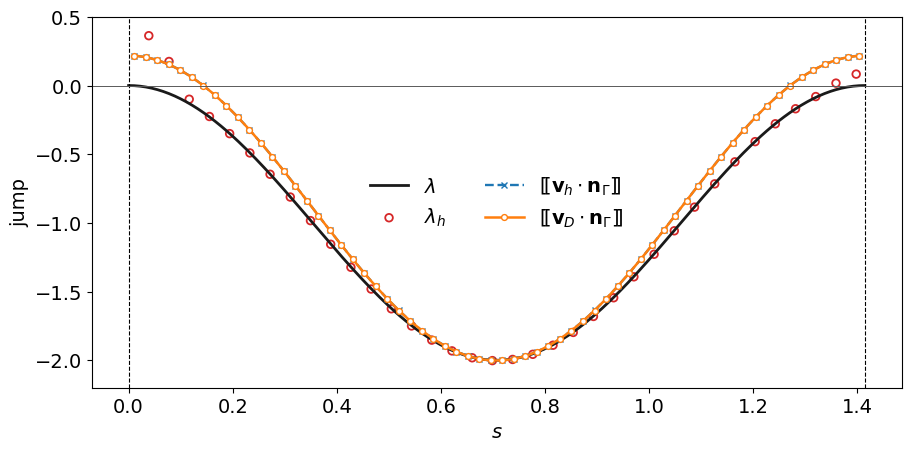

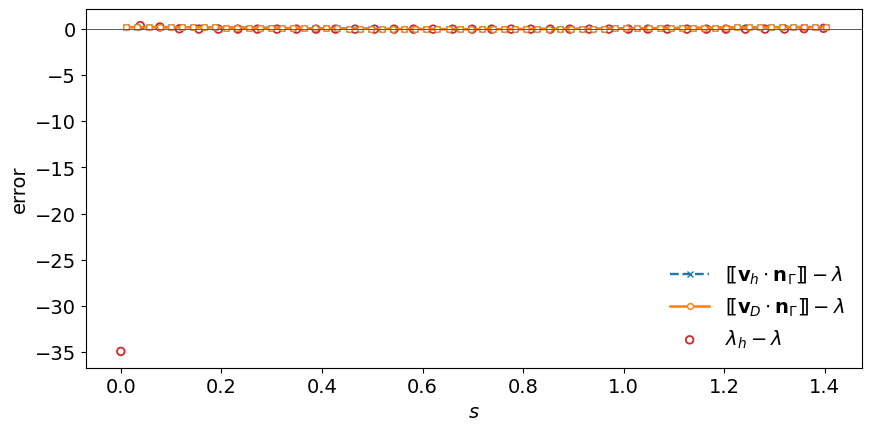

Real fracture jump vs lambda_exact (excluding 10% tips):
  CG    max=1.970e-01  mean=8.435e-02  L2=1.111e-01
  Deng  max=1.968e-01  mean=8.412e-02  L2=1.109e-01
  lam_h max=5.314e-03  mean=2.484e-03  L2=2.821e-03
No ghost extension: the physical fracture spans the full domain diagonal.


/tmp/ipykernel_114786/509536416.py:79: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  print(f"  CG    max={np.max(np.abs(err_cg_jump)):.3e}  mean={np.mean(np.abs(err_cg_jump)):.3e}  L2={np.sqrt(np.trapz(err_cg_jump**2, s_mid_jump[mask_mid])):.3e}")
/tmp/ipykernel_114786/509536416.py:80: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  print(f"  Deng  max={np.max(np.abs(err_deng_jump)):.3e}  mean={np.mean(np.abs(err_deng_jump)):.3e}  L2={np.sqrt(np.trapz(err_deng_jump**2, s_mid_jump[mask_mid])):.3e}")
/tmp/ipykernel_114786/509536416.py:81: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  print(f"  lam_h max={np.max(np.abs(err_lh)):.3e}  mean={np.mean(np.abs(err_lh)):.3e}  L2={np.sqrt(np.trapz(err_lh**2, s_real[mask_real]))

In [22]:
def cg_jump_on_fracture(ctx, gdata, s_query, eps=None):
    if eps is None:
        eps = 0.1 * gdata["h_est"]
    s_query = np.asarray(s_query, dtype=float).reshape(-1)
    x0 = gdata["real_points_np"](s_query)
    normal = gdata["normal_np"]
    qp = q_cg_numpy(ctx, gdata, x0 + eps * normal[None, :])
    qm = q_cg_numpy(ctx, gdata, x0 - eps * normal[None, :])
    return np.sum((qp - qm) * normal[None, :], axis=1)


def deng_jump_on_fracture(ctx, local_fluxes, gdata, s_query, eps=None):
    if eps is None:
        eps = 0.1 * gdata["h_est"]
    s_query = np.asarray(s_query, dtype=float).reshape(-1)
    x0 = gdata["real_points_np"](s_query)
    normal = gdata["normal_np"]
    qp = q_rec_numpy(ctx, local_fluxes, gdata, x0 + eps * normal[None, :])
    qm = q_rec_numpy(ctx, local_fluxes, gdata, x0 - eps * normal[None, :])
    return np.sum((qp - qm) * normal[None, :], axis=1)


N_REAL = max(128, 4 * len(ctx_demo["gamma_entities"]))
s_real = np.linspace(0.0, gdata_demo["L_gamma"], N_REAL)
x_real = gdata_demo["real_points_np"](s_real)
lambda_h_real = lambda_h_on_s(ctx_demo, gdata_demo, s_real)
lambda_exact_real = lam_exact_fn(x_real[:, 0])

# Use fracture-segment midpoints for CG and Deng jump comparison.
dof_t_jump = np.sort(ctx_demo["V_l"].tabulate_dof_coordinates()[:, 0])
t_mid_jump = 0.5 * (dof_t_jump[:-1] + dof_t_jump[1:])
x_mid_jump = np.column_stack([t_mid_jump, t_mid_jump])
s_mid_jump = gdata_demo["s_coord_np"](x_mid_jump)
lambda_exact_mid = lam_exact_fn(t_mid_jump)
jump_cg_mid = cg_jump_on_fracture(ctx_demo, gdata_demo, s_mid_jump)
jump_deng_mid = deng_jump_on_fracture(ctx_demo, lf_demo, gdata_demo, s_mid_jump)

fig, ax = plt.subplots(figsize=(9.0, 4.4), constrained_layout=True)
ax.plot(s_real, lambda_exact_real, color="0.10", lw=2.0, label=r"$\lambda$")
ax.scatter(s_real[::max(N_REAL // 34, 1)], lambda_h_real[::max(N_REAL // 34, 1)],
           s=30, facecolors="none", edgecolors="tab:red", linewidths=1.3, label=r"$\lambda_h$")
ax.plot(s_mid_jump, jump_cg_mid, "--", color="tab:blue", lw=1.7, marker="x", ms=4.5,
        markevery=max(len(s_mid_jump) // 34, 1), label=r"$[\![\mathbf{v}_h\cdot\mathbf{n}_\Gamma]\!]$")
ax.plot(s_mid_jump, jump_deng_mid, "-", color="tab:orange", lw=1.8, marker="o", ms=4.2,
        mfc="white", markevery=max(len(s_mid_jump) // 34, 1), label=r"$[\![\mathbf{v}_D\cdot\mathbf{n}_\Gamma]\!]$")
ax.axvline(0.0, color="k", ls="--", lw=0.8)
ax.axvline(gdata_demo["L_gamma"], color="k", ls="--", lw=0.8)
ax.axhline(0.0, color="0.35", lw=0.7)
ax.set_xlabel(r"$s$")
ax.set_ylabel(r"jump")
ax.set_ylim([-2.2,0.5])
ax.grid(False)
ax.legend(frameon=False, ncol=2, handlelength=2.0)
plt.show()

fig, ax = plt.subplots(figsize=(8.6, 4.2), constrained_layout=True)
ax.plot(s_mid_jump, jump_cg_mid - lambda_exact_mid, "--", color="tab:blue", lw=1.7,
        marker="x", ms=4.5, markevery=max(len(s_mid_jump) // 34, 1),
        label=r"$[\![\mathbf{v}_h\cdot\mathbf{n}_\Gamma]\!]-\lambda$")
ax.plot(s_mid_jump, jump_deng_mid - lambda_exact_mid, "-", color="tab:orange", lw=1.8,
        marker="o", ms=4.2, mfc="white", markevery=max(len(s_mid_jump) // 34, 1),
        label=r"$[\![\mathbf{v}_D\cdot\mathbf{n}_\Gamma]\!]-\lambda$")
ax.scatter(s_real[::max(N_REAL // 34, 1)], (lambda_h_real - lambda_exact_real)[::max(N_REAL // 34, 1)],
           s=30, facecolors="none", edgecolors="tab:red", linewidths=1.3,
           label=r"$\lambda_h-\lambda$")
ax.axhline(0.0, color="0.35", lw=0.7)
ax.set_xlabel(r"$s$")
ax.set_ylabel("error")
ax.grid(False)
ax.legend(frameon=False, handlelength=2.0)
plt.show()

mask_mid = (s_mid_jump >= TIP_FRAC * gdata_demo["L_gamma"]) & (s_mid_jump <= (1.0 - TIP_FRAC) * gdata_demo["L_gamma"])
mask_real = (s_real >= TIP_FRAC * gdata_demo["L_gamma"]) & (s_real <= (1.0 - TIP_FRAC) * gdata_demo["L_gamma"])
err_cg_jump = jump_cg_mid[mask_mid] - lambda_exact_mid[mask_mid]
err_deng_jump = jump_deng_mid[mask_mid] - lambda_exact_mid[mask_mid]
err_lh = lambda_h_real[mask_real] - lambda_exact_real[mask_real]
print(f"Real fracture jump vs lambda_exact (excluding {TIP_FRAC*100:.0f}% tips):")
print(f"  CG    max={np.max(np.abs(err_cg_jump)):.3e}  mean={np.mean(np.abs(err_cg_jump)):.3e}  L2={np.sqrt(np.trapz(err_cg_jump**2, s_mid_jump[mask_mid])):.3e}")
print(f"  Deng  max={np.max(np.abs(err_deng_jump)):.3e}  mean={np.mean(np.abs(err_deng_jump)):.3e}  L2={np.sqrt(np.trapz(err_deng_jump**2, s_mid_jump[mask_mid])):.3e}")
print(f"  lam_h max={np.max(np.abs(err_lh)):.3e}  mean={np.mean(np.abs(err_lh)):.3e}  L2={np.sqrt(np.trapz(err_lh**2, s_real[mask_real])):.3e}")

# Ghost-extension jump magnitude. For the full-diagonal MMS this block prints
# that no ghost extension is present.
x_ghost = gdata_demo["ghost_points_np"](n_each=max(64, N_REAL // 2))
if len(x_ghost):
    s_ghost = gdata_demo["s_coord_np"](x_ghost)
    jump_cg_ghost = cg_jump_on_fracture(ctx_demo, gdata_demo, s_ghost)
    jump_deng_ghost = deng_jump_on_fracture(ctx_demo, lf_demo, gdata_demo, s_ghost)
    fig, ax = plt.subplots(figsize=(8.6, 4.2), constrained_layout=True)
    ax.semilogy(s_ghost, np.abs(jump_cg_ghost) + 1e-30, "--", color="tab:blue", lw=1.7,
                label=r"$|[\![\mathbf{v}_h\cdot\mathbf{n}_\Gamma]\!]|$")
    ax.semilogy(s_ghost, np.abs(jump_deng_ghost) + 1e-30, "-", color="tab:orange", lw=1.8,
                label=r"$|[\![\mathbf{v}_D\cdot\mathbf{n}_\Gamma]\!]|$")
    ax.set_xlabel(r"$s$")
    ax.set_ylabel("magnitude")
    ax.grid(True, which="both", alpha=0.22)
    ax.legend(frameon=False, handlelength=2.0)
    plt.show()
else:
    print("No ghost extension: the physical fracture spans the full domain diagonal.")


## 3. Residual maps: element-wise and control-volume-wise

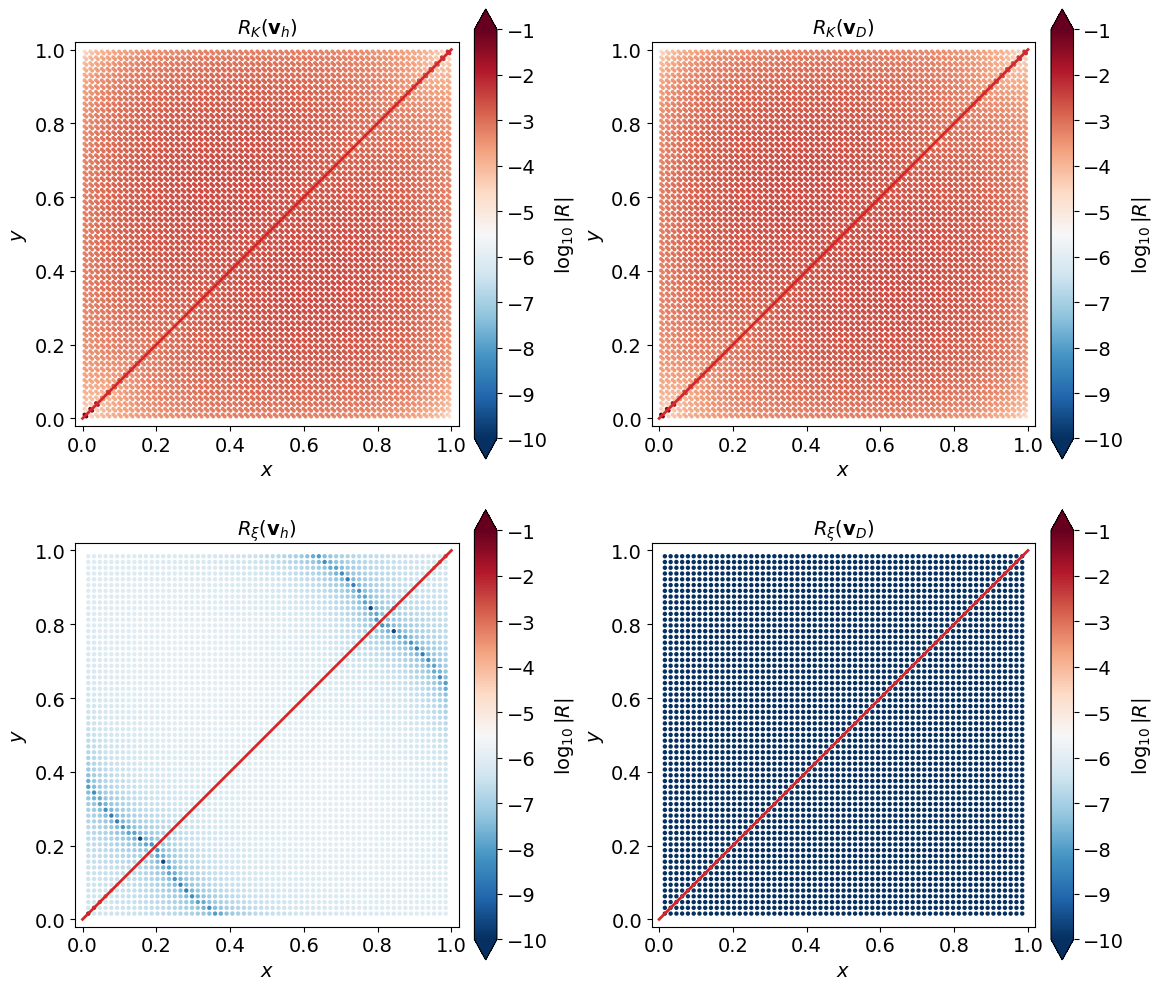

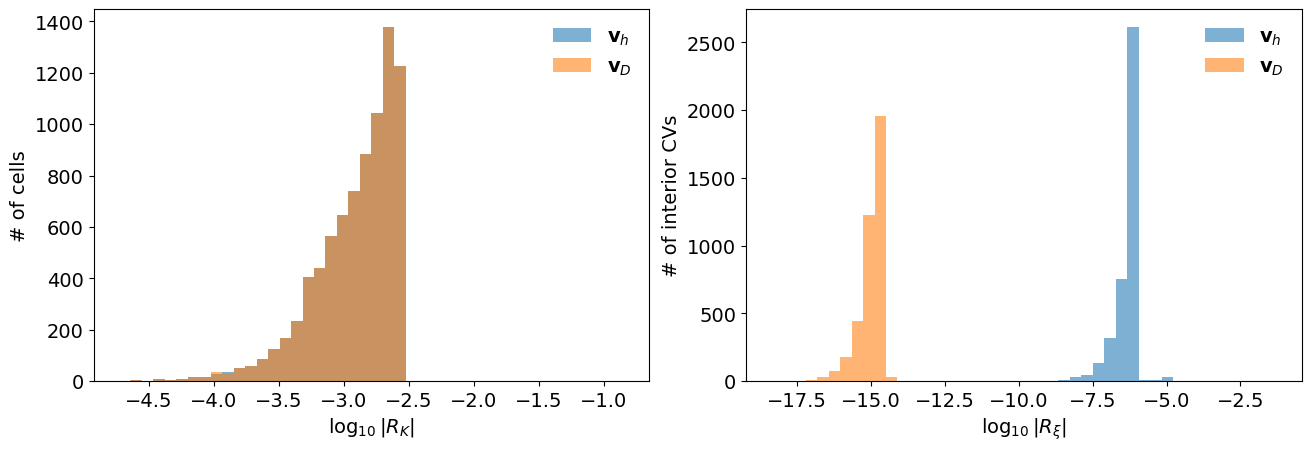

In [18]:
def _log_res(values, eps=1e-30):
    return np.log10(np.abs(values) + eps)


def _map_extend(log_values):
    lo = np.nanmin(log_values)
    hi = np.nanmax(log_values)
    if lo < RK_LOG_VMIN and hi > RK_LOG_VMAX:
        return "both"
    if lo < RK_LOG_VMIN:
        return "min"
    if hi > RK_LOG_VMAX:
        return "max"
    return "neither"


cent = gdata_demo["cell_centroids"]
verts_xy = gdata_demo["omega_geometry"]
cv_plot_ids = interior_cv_ids
map_specs = [
    ("Element", r"$R_K(\mathbf{v}_h)$", cent, R_elem_cg),
    ("Element", r"$R_K(\mathbf{v}_D)$", cent, R_elem_rec),
    ("CV", r"$R_\xi(\mathbf{v}_h)$", verts_xy[cv_plot_ids], R_cv_cg[cv_plot_ids]),
    ("CV", r"$R_\xi(\mathbf{v}_D)$", verts_xy[cv_plot_ids], R_cv_rec[cv_plot_ids]),
]
all_logs = np.concatenate([_log_res(vals) for _, _, _, vals in map_specs])
extend = _map_extend(all_logs)

fig, axes = plt.subplots(2, 2, figsize=(11.5, 10.0), constrained_layout=True)
for ax, (kind, title, xy, vals) in zip(axes.ravel(), map_specs):
    sc = ax.scatter(
        xy[:, 0], xy[:, 1], c=_log_res(vals), s=8 if kind == "Element" else 10,
        cmap="RdBu_r", vmin=RK_LOG_VMIN, vmax=RK_LOG_VMAX,
        linewidths=0.0, rasterized=True,
    )
    plot_fracture_lines(ax, gdata_demo)
    ax.set_aspect("equal")
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    ax.set_title(title)
    ax.grid(False)
    ax.set_xlabel(r"$x$")
    ax.set_ylabel(r"$y$")
    cbar = fig.colorbar(sc, ax=ax, label=r"$\log_{10}|R|$", extend=extend, pad=0.02)
    cbar.set_ticks(RK_CBAR_TICKS)
plt.show()

# Distribution over all matrix cells and all interior CVs.
fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.4), constrained_layout=True)
lo_e = min(_log_res(R_elem_cg).min(), _log_res(R_elem_rec).min())
hi_e = max(_log_res(R_elem_cg).max(), _log_res(R_elem_rec).max())
bins_e = np.linspace(lo_e, hi_e, 45)
axes[0].hist(_log_res(R_elem_cg), bins=bins_e, alpha=0.58, label=r"$\mathbf{v}_h$", color="tab:blue")
axes[0].hist(_log_res(R_elem_rec), bins=bins_e, alpha=0.58, label=r"$\mathbf{v}_D$", color="tab:orange")
axes[0].set_xlabel(r"$\log_{10}|R_K|$")
axes[0].set_ylabel("# of cells")
axes[0].grid(False)
axes[0].legend(frameon=False)

lo_cv = min(_log_res(R_cv_cg[interior_cv_ids]).min(), _log_res(R_cv_rec[interior_cv_ids]).min())
hi_cv = max(_log_res(R_cv_cg[interior_cv_ids]).max(), _log_res(R_cv_rec[interior_cv_ids]).max())
bins_cv = np.linspace(lo_cv, hi_cv, 45)
axes[1].hist(_log_res(R_cv_cg[interior_cv_ids]), bins=bins_cv, alpha=0.58, label=r"$\mathbf{v}_h$", color="tab:blue")
axes[1].hist(_log_res(R_cv_rec[interior_cv_ids]), bins=bins_cv, alpha=0.58, label=r"$\mathbf{v}_D$", color="tab:orange")
axes[1].set_xlabel(r"$\log_{10}|R_\xi|$")
axes[1].set_ylabel("# of interior CVs")
axes[1].grid(False)
axes[1].legend(frameon=False)
plt.show()

## 4. Quantitative comparison table

In [19]:
def print_stats_block(label, before, after, ids_all, ids_focus, focus_label):
    b_all = residual_stats(before, ids_all)
    a_all = residual_stats(after, ids_all)
    b_focus = residual_stats(before, ids_focus)
    a_focus = residual_stats(after, ids_focus)
    imp = improvement_stats(before, after, ids_focus)

    print(label)
    print(f"  all/interior count     = {b_all['n']}")
    print(f"  focus count ({focus_label}) = {b_focus['n']}")
    print(f"  CG    mean={b_all['mean']:.3e} median={b_all['median']:.3e} max={b_all['max']:.3e} | focus mean={b_focus['mean']:.3e} max={b_focus['max']:.3e}")
    print(f"  Deng  mean={a_all['mean']:.3e} median={a_all['median']:.3e} max={a_all['max']:.3e} | focus mean={a_focus['mean']:.3e} max={a_focus['max']:.3e}")
    print(f"  focus improved={imp[0]:.1f}% ratio mean={imp[1]:.3e} median={imp[2]:.3e} max={imp[3]:.3e}")
    print()
    return b_all, a_all, b_focus, a_focus, imp


all_cell_ids = np.arange(gdata_demo["num_cells"], dtype=np.int32)
print("Quantitative local-conservation comparison")
print(f"ref={REF_DEMO}, h={ctx_demo['h']:.4e}, total computation time={total_computation_time:.4f} s")
print()
elem_stats = print_stats_block(
    "Element-wise residual R_K",
    R_elem_cg, R_elem_rec, all_cell_ids, frac_cell_ids, "fracture-adjacent cells"
)
cv_stats = print_stats_block(
    "Control-volume residual R_xi",
    R_cv_cg, R_cv_rec, interior_cv_ids, fracture_cv_ids, "interior fracture CVs"
)


Quantitative local-conservation comparison
ref=6, h=1.5625e-02, total computation time=54.9625 s

Element-wise residual R_K
  all/interior count     = 8192
  focus count (fracture-adjacent cells) = 128
  CG    mean=1.545e-03 median=1.486e-03 max=1.438e-01 | focus mean=4.474e-03 max=1.438e-01
  Deng  mean=1.545e-03 median=1.486e-03 max=1.438e-01 | focus mean=4.474e-03 max=1.438e-01
  focus improved=45.3% ratio mean=1.001e+00 median=1.002e+00 max=1.025e+00

Control-volume residual R_xi
  all/interior count     = 3969
  focus count (interior fracture CVs) = 63
  CG    mean=1.950e-05 median=7.215e-07 max=5.174e-02 | focus mean=1.190e-03 max=5.174e-02
  Deng  mean=1.584e-15 median=1.352e-15 max=5.125e-13 | focus mean=1.481e-14 max=5.125e-13
  focus improved=100.0% ratio mean=9.185e-09 median=2.832e-10 max=4.096e-07

LaTeX table:
\begin{table}[H]
\centering
\caption{Local conservation residuals before and after Deng reconstruction for the conforming fractured MMS test.}
\label{tab:deng_fract

## 5. Local conservation around the fracture

Fracture-adjacent cells      : 128
Interior fracture CV vertices: 63


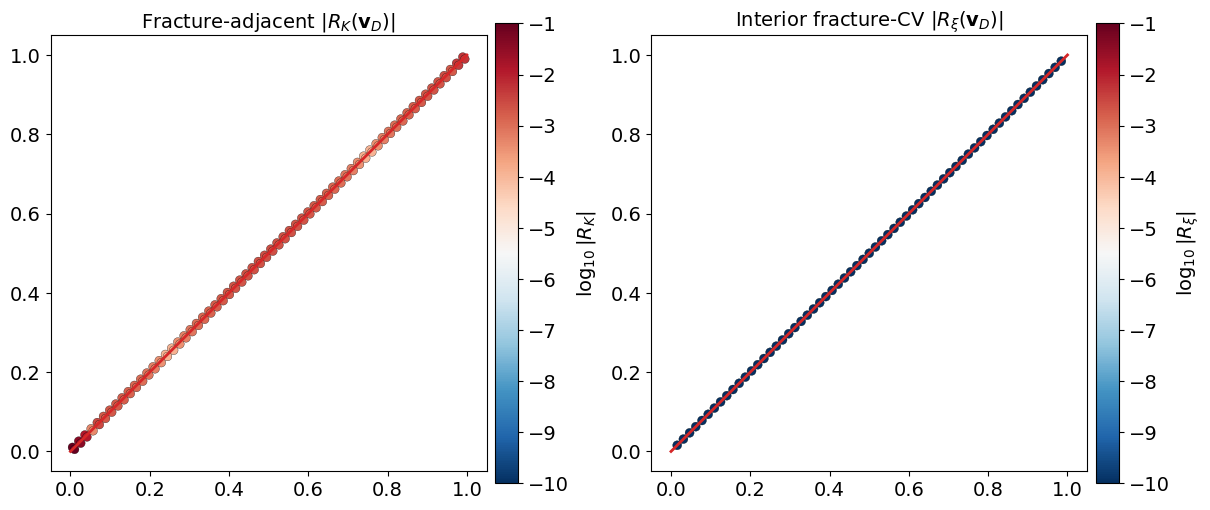

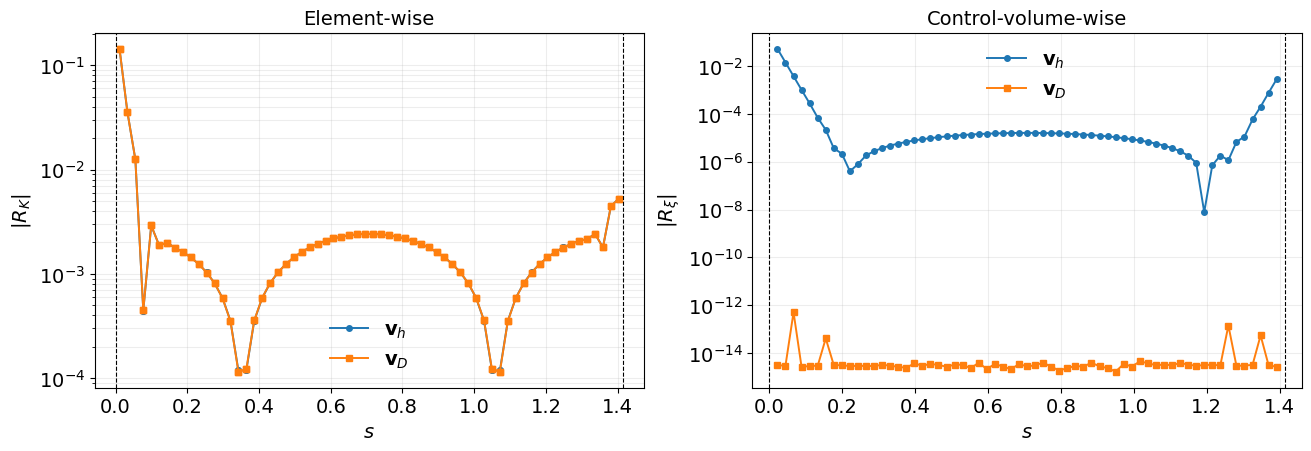


Fracture-adjacent element residuals (n=128):
  CG    mean=4.474e-03 median=1.625e-03 max=1.438e-01
  Deng  mean=4.474e-03 median=1.626e-03 max=1.438e-01
  improved=45.3% ratio mean=1.001e+00 median=1.002e+00 max=1.025e+00

Interior fracture-CV residuals (n=63):
  CG    mean=1.190e-03 median=1.137e-05 max=5.174e-02
  Deng  mean=1.481e-14 median=3.066e-15 max=5.125e-13
  improved=100.0% ratio mean=9.185e-09 median=2.832e-10 max=4.096e-07


In [20]:
cent_frac = gdata_demo["cell_centroids"][frac_cell_ids]
s_elem_frac = gdata_demo["s_coord_np"](cent_frac) if len(frac_cell_ids) else np.array([])
verts_frac = gdata_demo["omega_geometry"][fracture_cv_ids]
s_cv_frac = gdata_demo["s_coord_np"](verts_frac) if len(fracture_cv_ids) else np.array([])

print(f"Fracture-adjacent cells      : {len(frac_cell_ids)}")
print(f"Interior fracture CV vertices: {len(fracture_cv_ids)}")

fig, axes = plt.subplots(1, 2, figsize=(12.0, 5.0), constrained_layout=True)
if len(frac_cell_ids):
    sc0 = axes[0].scatter(
        cent_frac[:, 0], cent_frac[:, 1], c=_log_res(R_elem_rec[frac_cell_ids]),
        s=40, cmap="RdBu_r", vmin=RK_LOG_VMIN, vmax=RK_LOG_VMAX,
        edgecolors="k", linewidths=0.2, rasterized=True,
    )
    plot_fracture_lines(axes[0], gdata_demo)
    axes[0].set_title(r"Fracture-adjacent $|R_K(\mathbf{v}_D)|$")
    axes[0].set_aspect("equal")
    axes[0].grid(False)
    fig.colorbar(sc0, ax=axes[0], label=r"$\log_{10}|R_K|$", pad=0.02)
else:
    axes[0].set_title("No fracture-adjacent cells")

if len(fracture_cv_ids):
    sc1 = axes[1].scatter(
        verts_frac[:, 0], verts_frac[:, 1], c=_log_res(R_cv_rec[fracture_cv_ids]),
        s=42, cmap="RdBu_r", vmin=RK_LOG_VMIN, vmax=RK_LOG_VMAX,
        edgecolors="k", linewidths=0.2, rasterized=True,
    )
    plot_fracture_lines(axes[1], gdata_demo)
    axes[1].set_title(r"Interior fracture-CV $|R_\xi(\mathbf{v}_D)|$")
    axes[1].set_aspect("equal")
    axes[1].grid(False)
    fig.colorbar(sc1, ax=axes[1], label=r"$\log_{10}|R_\xi|$", pad=0.02)
else:
    axes[1].set_title("No interior fracture CVs")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.4), constrained_layout=True)
if len(frac_cell_ids):
    idx = np.argsort(s_elem_frac)
    axes[0].semilogy(s_elem_frac[idx], np.abs(R_elem_cg[frac_cell_ids][idx]) + 1e-30,
                     "o-", ms=4, lw=1.4, label=r"$\mathbf{v}_h$")
    axes[0].semilogy(s_elem_frac[idx], np.abs(R_elem_rec[frac_cell_ids][idx]) + 1e-30,
                     "s-", ms=4, lw=1.4, label=r"$\mathbf{v}_D$")
    axes[0].axvline(0.0, color="k", ls="--", lw=0.8)
    axes[0].axvline(gdata_demo["L_gamma"], color="k", ls="--", lw=0.8)
    axes[0].set_xlabel(r"$s$")
    axes[0].set_ylabel(r"$|R_K|$")
    axes[0].set_title("Element-wise")
    axes[0].grid(True, which="both", alpha=0.22)
    axes[0].legend(frameon=False)

if len(fracture_cv_ids):
    idx = np.argsort(s_cv_frac)
    axes[1].semilogy(s_cv_frac[idx], np.abs(R_cv_cg[fracture_cv_ids][idx]) + 1e-30,
                     "o-", ms=4, lw=1.4, label=r"$\mathbf{v}_h$")
    axes[1].semilogy(s_cv_frac[idx], np.abs(R_cv_rec[fracture_cv_ids][idx]) + 1e-30,
                     "s-", ms=4, lw=1.4, label=r"$\mathbf{v}_D$")
    axes[1].axvline(0.0, color="k", ls="--", lw=0.8)
    axes[1].axvline(gdata_demo["L_gamma"], color="k", ls="--", lw=0.8)
    axes[1].set_xlabel(r"$s$")
    axes[1].set_ylabel(r"$|R_\xi|$")
    axes[1].set_title("Control-volume-wise")
    axes[1].grid(True, which="both", alpha=0.22)
    axes[1].legend(frameon=False)
plt.show()

for label, before, after, ids in [
    ("Fracture-adjacent element residuals", R_elem_cg, R_elem_rec, frac_cell_ids),
    ("Interior fracture-CV residuals", R_cv_cg, R_cv_rec, fracture_cv_ids),
]:
    b = residual_stats(before, ids)
    a = residual_stats(after, ids)
    imp = improvement_stats(before, after, ids)
    print(f"\n{label} (n={b['n']}):")
    print(f"  CG    mean={b['mean']:.3e} median={b['median']:.3e} max={b['max']:.3e}")
    print(f"  Deng  mean={a['mean']:.3e} median={a['median']:.3e} max={a['max']:.3e}")
    print(f"  improved={imp[0]:.1f}% ratio mean={imp[1]:.3e} median={imp[2]:.3e} max={imp[3]:.3e}")